In [1]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
%matplotlib inline

In [2]:
data = pd.read_csv('../dataset/vagalume_processed.csv')

In [3]:
data['genre'].unique()

array(['axe', 'gospel', 'rock', 'pop', 'sertanejo', 'samba', 'mpb',
       'funk-carioca', 'pagode', 'forro', 'infantil', 'bossa-nova',
       'jovem-guarda', 'velha-guarda'], dtype=object)

In [4]:
filtered_data = filter(lambda x: type(x) == str, data['processed_music_lyric'].to_list())

In [5]:
vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=30)
vectorizer.fit(list(filtered_data))

TfidfVectorizer(max_features=30, ngram_range=(1, 2))

In [6]:
selected_genre = 'funk-carioca'
genre_data = filter(lambda x: type(x) == str, data[data['genre'] == selected_genre]['processed_music_lyric'])

In [7]:
tfidf_genre = vectorizer.transform(list(genre_data))

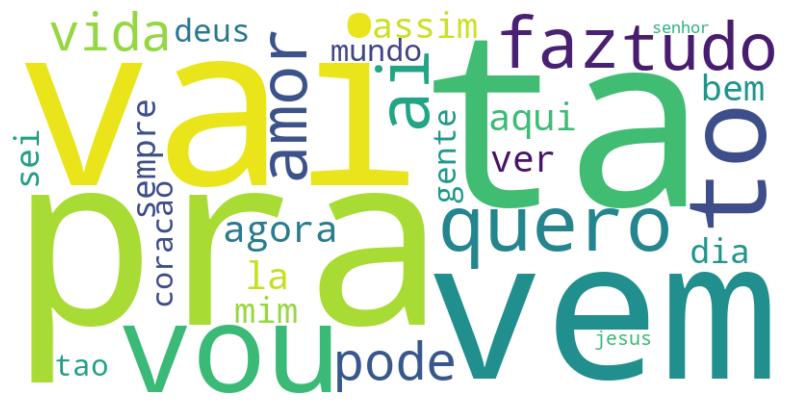

In [8]:
tfidf_sum = tfidf_genre.sum(axis=0)

# Criar um dicionário de palavra -> tf-idf
words = vectorizer.get_feature_names_out()
tfidf_dict = {words[i]: tfidf_sum[0, i] for i in range(len(words))}

# Gerar a WordCloud com o TF-IDF como peso das palavras
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(tfidf_dict)

# Mostrar a WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [9]:
# Create and generate a word cloud image:
# wordcloud = WordCloud().generate(' '.join(funk_lyrics_list))
# wordcloud = WordCloud().generate_from_frequencies(vectorizer.vocabulary_)

# # Display the generated image:
# plt.imshow(wordcloud, interpolation='bilinear')
# plt.axis("off")
# plt.show()